In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [2]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/interim") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data/interim'

### 1. 讀取資料

In [4]:
file_path = Path("/Users/kaiping/Desktop/olist_project/data/interim/orders_delivered_base.csv")

orders_delivered_base = pd.read_csv(file_path)

print("原始資料筆數：", orders_delivered_base.shape[0])
print("原始欄位數：", orders_delivered_base.shape[1])
orders_delivered_base.head()

原始資料筆數： 96478
原始欄位數： 10


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02-01


In [6]:
# =========================
# 2. 日期欄位轉型
# =========================
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders_delivered_base[col] = pd.to_datetime(orders_delivered_base[col], errors="coerce")

orders_delivered_base[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [7]:
# 3. 設定分析截止日
data_end = pd.Timestamp("2018-08-29 15:00:00")
analysis_end = pd.Timestamp("2018-05-31 15:00:00")

orders_delivered_base = orders_delivered_base.loc[
    orders_delivered_base["order_purchase_timestamp"] <= analysis_end
].copy()

print("截斷後資料筆數：", orders_delivered_base.shape[0])
print("截斷後客戶唯一值數量：", orders_delivered_base["customer_unique_id"].nunique())
print("下單時間範圍：")
print("min =", orders_delivered_base["order_purchase_timestamp"].min())
print("max =", orders_delivered_base["order_purchase_timestamp"].max())

截斷後資料筆數： 77799
截斷後客戶唯一值數量： 75320
下單時間範圍：
min = 2016-09-15 12:16:00
max = 2018-05-31 14:51:00


In [13]:
orders_delivered_base.isna().sum()


order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     2
order_estimated_delivery_date     0
purchase_month                    0
dtype: int64

### 2. order_timestamp gap=0 問題  
| 欄位                              | 意義       |
| ------------------------------- | -------- |
| `customer_unique_id`            | 顧客       |
| `prev_order_id`                 | 上一筆訂單    |
| `order_id`                      | 目前這筆訂單   |
| `prev_order_purchase_timestamp` | 上一筆訂單時間  |
| `order_purchase_timestamp`      | 目前訂單時間   |
| `gap_days`                      | 兩筆訂單間隔天數 |


In [9]:

# 依顧客與購買時間排序
orders_gap_detail = (
    orders_delivered_base
    .sort_values(
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    )
    .copy()
)

# 取得同一顧客的上一筆訂單資訊
orders_gap_detail["prev_order_id"] = (
    orders_gap_detail
    .groupby("customer_unique_id")["order_id"]
    .shift(1)
)

orders_gap_detail["prev_order_purchase_timestamp"] = (
    orders_gap_detail
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

# 計算與上一筆訂單的間隔天數
orders_gap_detail["gap_days"] = (
    orders_gap_detail["order_purchase_timestamp"]
    - orders_gap_detail["prev_order_purchase_timestamp"]
).dt.total_seconds() / 86400

# 只保留有上一筆訂單的紀錄
order_gap_pairs = orders_gap_detail.loc[
    orders_gap_detail["prev_order_id"].notna(),
    [
        "customer_unique_id",
        "prev_order_id",
        "order_id",
        "prev_order_purchase_timestamp",
        "order_purchase_timestamp",
        "gap_days"
    ]
].copy()

order_gap_pairs.head()

,customer_unique_id,prev_order_id,order_id,prev_order_purchase_timestamp,order_purchase_timestamp,gap_days
38857,004288347e5e88a27ded2bb23747066c,a61d617fbe5bd006e40d3a0988fc844b,08204559bebd39e09ee52dcb56d8faa2,2017-07-27 14:13:00,2018-01-14 07:36:00,170.724306
81665,00cc12a6d8b578b8ebd21ea4e2ae8b27,64307ceb91666760cf3ff463618302fd,d61b915b69851aec8a8865f36cfd793e,2017-03-21 19:25:00,2017-03-21 19:25:00,0.000000
47905,011575986092c30523ecb71ff10cb473,0f28d51fdd4828907bdc58b57f672e84,ed0a6265b5b0a292cd537214f401f1fc,2018-02-17 15:54:00,2018-04-18 21:58:00,60.252778
12113,011b4adcd54683b480c4d841250a987f,f05a68aaa0d8f89e758c7134d53fa22a,93b35affb86435b71ca01a6dd1eab2b1,2017-08-22 12:51:00,2018-02-15 11:40:00,176.950694
11983,012452d40dafae4df401bced74cdb490,ce2b4f2836d78829e4796213d536101e,e49d0607832db7c3b1343764225d8df6,2017-06-18 22:46:00,2018-05-14 12:12:00,329.559722


In [10]:
print(f"Total order-to-order gaps: {len(order_gap_pairs):,}")

Total order-to-order gaps: 2,479


In [12]:
gap_zero_orders = order_gap_pairs.loc[
    order_gap_pairs["gap_days"] == 0
].copy()

print(f"Gap = 0 order pairs: {len(gap_zero_orders):,}")
print(f"Gap = 0 rate: {len(gap_zero_orders) / len(order_gap_pairs):.2%}")

Gap = 0 order pairs: 661
Gap = 0 rate: 26.66%


在 order-level 的回購間隔檢查中，可以發現部分同一顧客的連續 order 之間 gap_days = 0。  
這代表若直接以 order_id 作為購買次數基礎，可能會將同一次購買中被拆分出的多筆訂單誤判為二購。

因此，本專案在後續 Retention Structure Analysis 與 First-to-Second Purchase Analysis 中，會將同一位 customer_unique_id 在相同 order_purchase_timestamp 下的多筆 order 合併為同一次 purchase event，以避免高估二購率與低估回購間隔。

In [16]:
# 資料清理

# 篩選留存分析必要欄位
retention_order_base = orders_delivered_base[
    [
        "customer_unique_id",
        "order_id",
        "order_purchase_timestamp"
    ]
].copy()
retention_order_base

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:00
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:00
5,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:00
6,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:00
...,...,...,...
96473,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:00
96474,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:00
96475,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:00
96476,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:00


In [17]:

# 同一顧客、同一購買時間，合併為同一次 purchase event
purchase_event_base = (
    retention_order_base
    .groupby(
        ["customer_unique_id", "order_purchase_timestamp"],
        as_index=False
    )
    .agg(
        order_count=("order_id", "nunique"),
        order_ids=("order_id", lambda x: ",".join(x.astype(str)))
    )
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .reset_index(drop=True)
)

purchase_event_base

,customer_unique_id,order_purchase_timestamp,order_count,order_ids
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7
...,...,...,...,...
77133,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,1,725cf8e9c24e679a8a5a32cb92c9ce1e
77134,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,1,c71b9252fd7b3b263aaa4cb09319a323
77135,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,1,fdc45e6c7555e6cb3cc0daca2557dbe1
77136,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,1,94d3ee0bc2a0af9d4fa47a4d63616e8d


### 3. 回購次數分析

In [21]:
# 計算每位顧客購買次數
customer_purchase_freq = (
    purchase_event_base
    .groupby("customer_unique_id", as_index=False)
    .agg(
        purchase_event_count=("order_purchase_timestamp", "count")
    )
)

customer_purchase_freq.head(5)

,customer_unique_id,purchase_event_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [25]:
# 購買次數分佈
purchase_count_dist = (
    customer_purchase_freq
    .groupby("purchase_event_count", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count")
    )
    .sort_values("purchase_event_count")
    .reset_index(drop=True)
)

# 單一購買次數占比
purchase_count_dist["customer_pct"] = (
    purchase_count_dist["customer_count"] 
    / purchase_count_dist["customer_count"].sum()
)

# 累積人數
purchase_count_dist["cum_customer_count"] = (
    purchase_count_dist["customer_count"].cumsum()
)

# 累積比例
purchase_count_dist["cum_rate"] = (
    purchase_count_dist["cum_customer_count"]
    / purchase_count_dist["customer_count"].sum()
)

# 格式整理
purchase_count_dist["customer_pct"] = purchase_count_dist["customer_pct"].round(4)
purchase_count_dist["cum_rate"] = purchase_count_dist["cum_rate"].round(4)

purchase_count_dist

,purchase_event_count,customer_count,customer_pct,cum_customer_count,cum_rate
0,1,73684,0.9783,73684,0.9783
1,2,1508,0.0200,75192,0.9983
2,3,100,0.0013,75292,0.9996
3,4,15,0.0002,75307,0.9998
4,5,6,0.0001,75313,0.9999
5,6,4,0.0001,75317,1.0000
6,7,2,0.0000,75319,1.0000
7,10,1,0.0000,75320,1.0000


In [23]:
# 計算一次性顧客和回購顧客（購買次數超過兩次) 比例
total_customers = customer_purchase_freq["customer_unique_id"].nunique()

one_time_customers = (
    customer_purchase_freq["purchase_event_count"].eq(1).sum()
)

repeat_customers = (
    customer_purchase_freq["purchase_event_count"].ge(2).sum()
)

print(f"Total customers: {total_customers:,}")
print(f"One-time customers: {one_time_customers:,} ({one_time_customers / total_customers:.2%})")
print(f"Repeat customers: {repeat_customers:,} ({repeat_customers / total_customers:.2%})")

Total customers: 75,320
One-time customers: 73,684 (97.83%)
Repeat customers: 1,636 (2.17%)


### 4.全體訂單回購間隔分析

In [28]:
# 依據顧客排序好後再根據每個顧客的購買時間排序
purchase_event_base = purchase_event_base.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
).reset_index(drop=True)

purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)
purchase_event_base

,customer_unique_id,order_purchase_timestamp,order_count,order_ids,purchase_event_rank
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7,1
...,...,...,...,...,...
77133,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,1,725cf8e9c24e679a8a5a32cb92c9ce1e,1
77134,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,1,c71b9252fd7b3b263aaa4cb09319a323,1
77135,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,1,fdc45e6c7555e6cb3cc0daca2557dbe1,1
77136,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,1,94d3ee0bc2a0af9d4fa47a4d63616e8d,1


In [29]:
# 計算所有 purchase event 的回購間隔
# 第1次 → 第2次
# 第2次 → 第3次
# 第3次 → 第4次
# ...


purchase_event_base["prev_event_ts"] = (
    purchase_event_base
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

purchase_event_base["prev_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")["purchase_event_rank"]
    .shift(1)
)

purchase_event_base["gap_days"] = (
    purchase_event_base["order_purchase_timestamp"]
    - purchase_event_base["prev_event_ts"]
).dt.total_seconds() / 86400

# 只保留有上一筆購買事件的紀錄
repurchase_gap_all = purchase_event_base.loc[
    purchase_event_base["prev_event_ts"].notna(),
    [
        "customer_unique_id",
        "prev_event_rank",
        "purchase_event_rank",
        "prev_event_ts",
        "order_purchase_timestamp",
        "gap_days"
    ]
].copy()

repurchase_gap_all

,customer_unique_id,prev_event_rank,purchase_event_rank,prev_event_ts,order_purchase_timestamp,gap_days
82,004288347e5e88a27ded2bb23747066c,1.0,2,2017-07-27 14:13:00,2018-01-14 07:36:00,170.724306
324,011575986092c30523ecb71ff10cb473,1.0,2,2018-02-17 15:54:00,2018-04-18 21:58:00,60.252778
338,011b4adcd54683b480c4d841250a987f,1.0,2,2017-08-22 12:51:00,2018-02-15 11:40:00,176.950694
348,012452d40dafae4df401bced74cdb490,1.0,2,2017-06-18 22:46:00,2018-05-14 12:12:00,329.559722
383,013f4353d26bb05dc6652f1269458d8d,1.0,2,2017-11-24 13:33:00,2017-11-28 13:30:00,3.997917
...,...,...,...,...,...,...
76778,fed519569d16e690df6f89cb99d4e682,1.0,2,2017-12-20 19:10:00,2018-03-18 21:51:00,88.111806
76836,ff03923ad1eb9e32304deb7f9b2a45c9,1.0,2,2018-04-23 21:49:00,2018-05-26 11:51:00,32.584722
77000,ff8892f7c26aa0446da53d01b18df463,1.0,2,2017-05-24 16:09:00,2017-11-26 23:25:00,186.302778
77017,ff922bdd6bafcdf99cb90d7f39cea5b3,1.0,2,2017-02-22 12:26:00,2017-08-23 13:15:00,182.034028


In [58]:
# 檢查是否有gap=0
gap_zero_1to2 = repurchase_gap_all.loc[
    repurchase_gap_all["gap_days"] == 0
]

print(f"First-to-second gap = 0 records: {len(gap_zero_1to2):,}")

First-to-second gap = 0 records: 0


In [59]:
# 購買間隔分佈
gap_desc = repurchase_gap_all["gap_days"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

print(gap_desc)

count    1818.000000
mean       87.993253
std        97.356475
min         0.000694
25%        12.097917
50%        50.110069
75%       135.182118
90%       234.577708
95%       296.935937
99%       390.560021
max       580.693750
Name: gap_days, dtype: float64


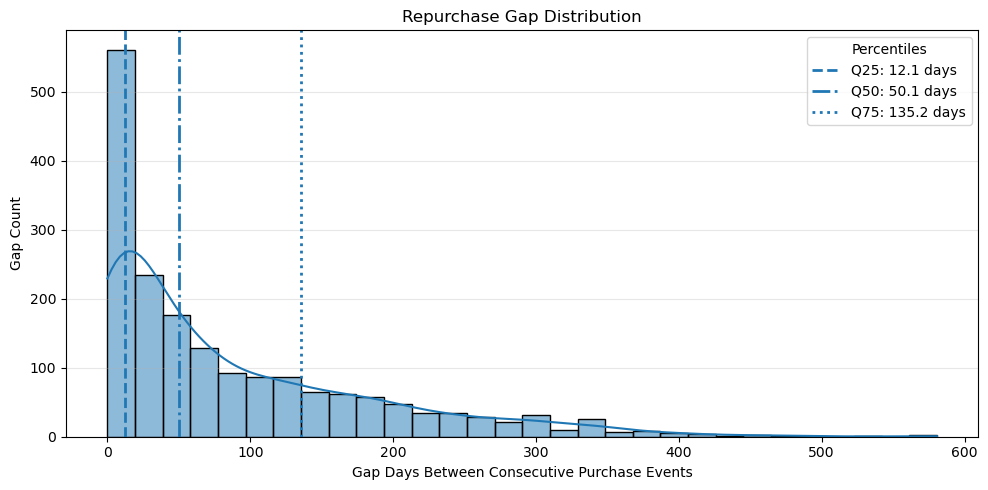

In [94]:
# 取出 gap 資料
gap_data = repurchase_gap_all["gap_days"].dropna()
gap_data = gap_data[gap_data >= 0]

# 計算分位數
q25 = gap_data.quantile(0.25)
q50 = gap_data.quantile(0.50)
q75 = gap_data.quantile(0.75)

plt.figure(figsize=(10, 5))

sns.histplot(
    gap_data,
    bins=30,
    kde=True
)

# 25分位數
plt.axvline(
    q25,
    linestyle="--",
    linewidth=2,
    label=f"Q25: {q25:.1f} days"
)

# 50分位數 / 中位數
plt.axvline(
    q50,
    linestyle="-.",
    linewidth=2,
    label=f"Q50: {q50:.1f} days"
)

# 75分位數
plt.axvline(
    q75,
    linestyle=":",
    linewidth=2,
    label=f"Q75: {q75:.1f} days"
)

plt.title("Repurchase Gap Distribution")
plt.xlabel("Gap Days Between Consecutive Purchase Events")
plt.ylabel("Gap Count")

plt.legend(title="Percentiles")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5. 首購二購間隔分析

In [95]:
# 清理首購與二購資料
# 確保 purchase_event_base 已排序
purchase_event_base = (
    purchase_event_base
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .copy()
)


purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)
purchase_event_base.head()

,customer_unique_id,order_purchase_timestamp,order_count,order_ids,purchase_event_rank,prev_event_ts,prev_event_rank,gap_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e,1,NaT,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9,1,NaT,NaN,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734,1,NaT,NaN,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6,1,NaT,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7,1,NaT,NaN,NaN


In [96]:
# 取出首購事件
first_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 1]
    [
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_count",
            "order_ids"
        ]
    ]
    .rename(columns={
        "order_purchase_timestamp": "first_purchase_ts",
        "order_count": "first_order_count",
        "order_ids": "first_order_ids"
    })
    .copy()
)

first_purchase.head()

,customer_unique_id,first_purchase_ts,first_order_count,first_order_ids
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7


In [97]:
# 取出二購事件
second_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 2]
    [
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_count",
            "order_ids"
        ]
    ]
    .rename(columns={
        "order_purchase_timestamp": "second_purchase_ts",
        "order_count": "second_order_count",
        "order_ids": "second_order_ids"
    })
    .copy()
)

second_purchase.head()

,customer_unique_id,second_purchase_ts,second_order_count,second_order_ids
82,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:00,1,08204559bebd39e09ee52dcb56d8faa2
324,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:00,1,ed0a6265b5b0a292cd537214f401f1fc
338,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:00,1,93b35affb86435b71ca01a6dd1eab2b1
348,012452d40dafae4df401bced74cdb490,2018-05-14 12:12:00,1,e49d0607832db7c3b1343764225d8df6
383,013f4353d26bb05dc6652f1269458d8d,2017-11-28 13:30:00,1,9eead354475b8b8fde3811f26b2599fc


In [98]:
# 合併首購與二購，計算 gap
first_to_second_gap = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="inner",
    validate="one_to_one"
)

first_to_second_gap["gap_days"] = (
    first_to_second_gap["second_purchase_ts"]
    - first_to_second_gap["first_purchase_ts"]
).dt.total_seconds() / 86400

first_to_second_gap.head()

,customer_unique_id,first_purchase_ts,first_order_count,first_order_ids,second_purchase_ts,second_order_count,second_order_ids,gap_days
0,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13:00,1,a61d617fbe5bd006e40d3a0988fc844b,2018-01-14 07:36:00,1,08204559bebd39e09ee52dcb56d8faa2,170.724306
1,011575986092c30523ecb71ff10cb473,2018-02-17 15:54:00,1,0f28d51fdd4828907bdc58b57f672e84,2018-04-18 21:58:00,1,ed0a6265b5b0a292cd537214f401f1fc,60.252778
2,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51:00,1,f05a68aaa0d8f89e758c7134d53fa22a,2018-02-15 11:40:00,1,93b35affb86435b71ca01a6dd1eab2b1,176.950694
3,012452d40dafae4df401bced74cdb490,2017-06-18 22:46:00,1,ce2b4f2836d78829e4796213d536101e,2018-05-14 12:12:00,1,e49d0607832db7c3b1343764225d8df6,329.559722
4,013f4353d26bb05dc6652f1269458d8d,2017-11-24 13:33:00,1,ddc5df3b1c497720bae1692c170baec0,2017-11-28 13:30:00,1,9eead354475b8b8fde3811f26b2599fc,3.997917


In [99]:
print(f"First purchase customers: {first_purchase['customer_unique_id'].nunique():,}")
print(f"Second purchase customers: {second_purchase['customer_unique_id'].nunique():,}")
print(f"First-to-second gap records: {len(first_to_second_gap):,}")

First purchase customers: 75,320
Second purchase customers: 1,636
First-to-second gap records: 1,636


In [57]:
# 檢查是否有gap=0
gap_zero_1to2 = first_to_second_gap.loc[
    first_to_second_gap["gap_days"] == 0
]

print(f"First-to-second gap = 0 records: {len(gap_zero_1to2):,}")

First-to-second gap = 0 records: 0


In [64]:
# 計算 60 / 90 / 120 天內完成二購的覆蓋率
days_list = [60, 90, 120]

coverage_df = pd.DataFrame({
    "days": days_list,
    "second_purchase_customer_count": [
        (first_to_second_gap["gap_days"] <= d).sum()
        for d in days_list
    ],
    "total_second_purchase_customers": len(first_to_second_gap),
    "coverage_rate": [
        (first_to_second_gap["gap_days"] <= d).mean()
        for d in days_list
    ]
})

coverage_df["coverage_rate_pct"] = (
    coverage_df["coverage_rate"] * 100
).round(2)

coverage_df

,days,second_purchase_customer_count,total_second_purchase_customers,coverage_rate,coverage_rate_pct
0,60,857,1636,0.523839,52.38
1,90,1024,1636,0.625917,62.59
2,120,1146,1636,0.700489,70.05


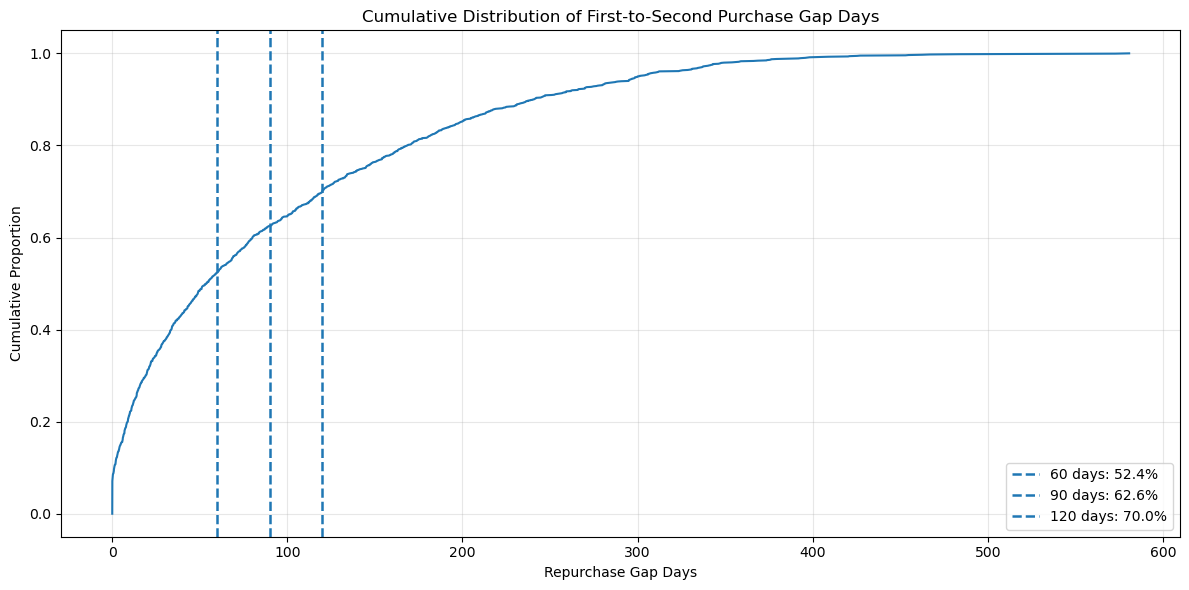

In [65]:
# gap CDF圖 (標記 60 / 90 / 120 天)
gap_sorted = np.sort(first_to_second_gap["gap_days"])
cum_prob = np.arange(1, len(gap_sorted) + 1) / len(gap_sorted)

plt.figure(figsize=(12, 6))

plt.plot(
    gap_sorted,
    cum_prob
)

for d in [60, 90, 120]:
    coverage = (first_to_second_gap["gap_days"] <= d).mean()
    
    plt.axvline(
        d,
        linestyle="--",
        linewidth=1.8,
        label=f"{d} days: {coverage:.1%}"
    )

plt.title("Cumulative Distribution of First-to-Second Purchase Gap Days")
plt.xlabel("Repurchase Gap Days")
plt.ylabel("Cumulative Proportion")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

本專案將 90 天定義為二購預測窗口，主要原因不是因為 90 天能完整涵蓋所有回購行為，而是因為本模型的目標是預測「早期二購轉化」。

根據首購到二購間隔分析，在已經發生二購的顧客中，約 62.59% 會在首購後 90 天內完成第二次購買。這表示 90 天能捕捉多數早期二購行為，並可作為平台進行首購後再行銷與成效追蹤的實務窗口。

若將預測窗口設定過短，例如 30 或 60 天，可能會漏掉較多正常二購顧客；若設定過長，例如 120 或 180 天，雖然能提高回購覆蓋率，但會降低行銷決策的即時性，並增加資料右截斷問題，使可用訓練樣本減少。

因此，本專案採用 90 天作為商業可操作性與資料覆蓋率之間的折衷。此定義應被解讀為「90 天內是否完成早期二購」，而非「顧客未來是否會永久回購」。

### 6. 每月首購cohort 90天內二購率分析

In [66]:

# 排序資料 (customer_unique_id, order_purchase_timestamp) 

purchase_event_base = purchase_event_base.copy()

purchase_event_base = purchase_event_base.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
).reset_index(drop=True)

purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)

In [67]:
# 取出每個顧客的首購事件
first_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 1,
         ["customer_unique_id", "order_purchase_timestamp"]]
    .rename(columns={
        "order_purchase_timestamp": "first_purchase_ts"
    })
    .copy()
)

first_purchase.head()

,customer_unique_id,first_purchase_ts
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00


In [68]:
# 取出每個顧客的二購事件
second_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 2,
         ["customer_unique_id", "order_purchase_timestamp"]]
    .rename(columns={
        "order_purchase_timestamp": "second_purchase_ts"
    })
    .copy()
)

second_purchase.head()

,customer_unique_id,second_purchase_ts
82,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:00
324,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:00
338,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:00
348,012452d40dafae4df401bced74cdb490,2018-05-14 12:12:00
383,013f4353d26bb05dc6652f1269458d8d,2017-11-28 13:30:00


In [69]:
# 首購二購分析表
first_to_second_cohort = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="left",
    validate="one_to_one"
)

first_to_second_cohort["gap_days"] = (
    first_to_second_cohort["second_purchase_ts"]
    - first_to_second_cohort["first_purchase_ts"]
).dt.total_seconds() / 86400

first_to_second_cohort.head()

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN


In [70]:
# 定義90天內是否回購
prediction_window_days = 90

first_to_second_cohort["second_purchase_within_90d"] = (
    first_to_second_cohort["gap_days"].le(prediction_window_days)
).astype(int)

first_to_second_cohort

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0
...,...,...,...,...,...
75315,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,NaT,NaN,0
75316,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,NaT,NaN,0
75317,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,NaT,NaN,0
75318,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,NaT,NaN,0


In [74]:
# 建立首購月份欄位
first_to_second_cohort["first_purchase_month"] = (
    first_to_second_cohort["first_purchase_ts"]
    .dt.to_period("M")
    .dt.to_timestamp()
)
first_to_second_cohort

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d,first_purchase_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0,2017-11-01
...,...,...,...,...,...,...
75315,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,NaT,NaN,0,2017-06-01
75316,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,NaT,NaN,0,2017-12-01
75317,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,NaT,NaN,0,2017-02-01
75318,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,NaT,NaN,0,2018-05-01


In [75]:
# 計算每月首購 Cohort 90 天二購率
monthly_cohort_90d = (
    first_to_second_cohort
    .groupby("first_purchase_month", as_index=False)
    .agg(
        cohort_size=("customer_unique_id", "nunique"),
        second_purchase_90d_count=("second_purchase_within_90d", "sum")
    )
    .sort_values("first_purchase_month")
    .reset_index(drop=True)
)

monthly_cohort_90d["second_purchase_90d_rate"] = (
    monthly_cohort_90d["second_purchase_90d_count"]
    / monthly_cohort_90d["cohort_size"]
)

monthly_cohort_90d["second_purchase_90d_rate_pct"] = (
    monthly_cohort_90d["second_purchase_90d_rate"] * 100
).round(2)

monthly_cohort_90d

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate,second_purchase_90d_rate_pct
0,2016-09-01,1,0,0.000000,0.00
1,2016-10-01,262,2,0.007634,0.76
2,2016-12-01,1,1,1.000000,100.00
3,2017-01-01,717,13,0.018131,1.81
4,2017-02-01,1628,16,0.009828,0.98
5,2017-03-01,2503,35,0.013983,1.40
6,2017-04-01,2256,32,0.014184,1.42
7,2017-05-01,3451,61,0.017676,1.77
8,2017-06-01,3037,59,0.019427,1.94
9,2017-07-01,3752,54,0.014392,1.44


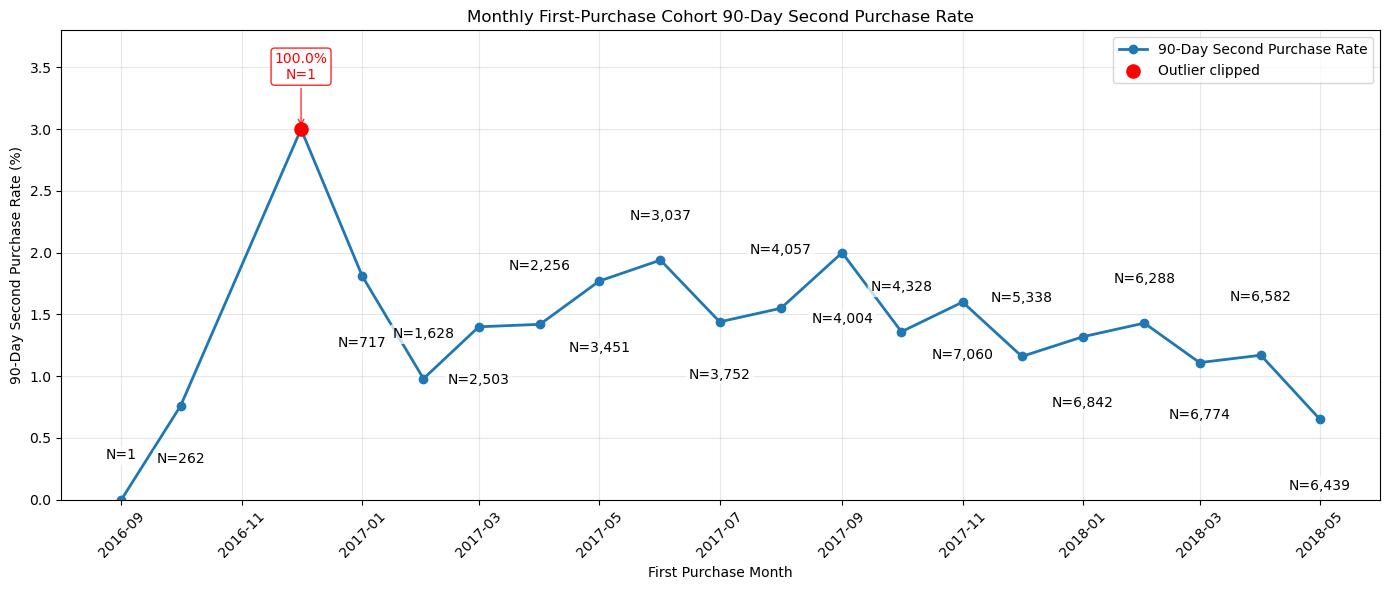

In [82]:
import matplotlib.dates as mdates

# 複製資料，避免直接修改原始 monthly_cohort_90d
plot_df = monthly_cohort_90d.copy()

# 將首購月份轉成 datetime，方便 x 軸以月份格式呈現
plot_df["first_purchase_month"] = pd.to_datetime(
    plot_df["first_purchase_month"]
)

# 重設 index，確保後續標註位置可穩定交錯排列
plot_df = plot_df.reset_index(drop=True)

# 設定 y 軸上限，讓主要二購率區間 0%~3% 更容易觀察
# 若有極端值，例如早期 cohort 因樣本數太小導致 100%，會被裁切顯示
y_cap = 3.0

# 判斷哪些 cohort 的二購率超過 y 軸上限
plot_df["is_outlier_rate"] = (
    plot_df["second_purchase_90d_rate_pct"] > y_cap
)

# 為了視覺化，將超過 y_cap 的點壓在 y_cap 位置顯示
# 原始數值仍保留在 second_purchase_90d_rate_pct 欄位中
plot_df["rate_for_plot"] = np.where(
    plot_df["is_outlier_rate"],
    y_cap,
    plot_df["second_purchase_90d_rate_pct"]
)

plt.figure(figsize=(14, 6))

# 繪製每月首購 cohort 的 90 天二購率折線圖
plt.plot(
    plot_df["first_purchase_month"],
    plot_df["rate_for_plot"],
    marker="o",
    linewidth=2,
    label="90-Day Second Purchase Rate"
)

# 取出被裁切的極端值 cohort
outliers = plot_df.loc[plot_df["is_outlier_rate"]].copy()

# 將被裁切的極端值用紅色標示，提醒讀者該點不是實際 y 值
plt.scatter(
    outliers["first_purchase_month"],
    outliers["rate_for_plot"],
    color="red",
    s=90,
    zorder=5,
    label="Outlier clipped"
)

# 標註一般 cohort 的樣本數
# 使用上下交錯方式，降低標籤互相重疊的機率
offset_pattern = [32, -38, 42, -48]

for i, row in plot_df.iterrows():

    # 極端值另外標註，避免與一般 cohort 標註邏輯混在一起
    if row["is_outlier_rate"]:
        continue

    offset_y = offset_pattern[i % len(offset_pattern)]

    plt.annotate(
        f'N={row["cohort_size"]:,}',
        xy=(row["first_purchase_month"], row["rate_for_plot"]),
        xytext=(0, offset_y),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.75
        )
    )

# 標註極端值的原始二購率與 cohort size
# 讓讀者知道紅點只是被裁切顯示，不代表真實值等於 y_cap
for _, row in outliers.iterrows():
    plt.annotate(
        f'{row["second_purchase_90d_rate_pct"]:.1f}%\nN={row["cohort_size"]:,}',
        xy=(row["first_purchase_month"], row["rate_for_plot"]),
        xytext=(0, 45),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        color="red",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="red",
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="red",
            alpha=0.8
        )
    )

plt.title("Monthly First-Purchase Cohort 90-Day Second Purchase Rate")
plt.xlabel("First Purchase Month")
plt.ylabel("90-Day Second Purchase Rate (%)")

# y 軸保留一點空間，避免標籤貼到圖表上緣
plt.ylim(0, y_cap + 0.8)

# x 軸以 YYYY-MM 顯示月份
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

排除早期樣本數過小的 cohort 後，平台每月首購 cohort 的 90 天二購率大多維持在 1%–2% 之間，整體未呈現明顯改善。2018 年後段 cohort 的二購率甚至略低於 2017 年多數月份，顯示平台首購顧客轉化為二購顧客的能力長期偏弱。

### 7. 交叉對比每月訂單趨勢確認訂單增加是否會增加留存率


In [86]:
# 從 purchase_event_base 清理每月購買事件趨勢


event_df = purchase_event_base.copy()

# 確保時間欄位為 datetime
event_df["order_purchase_timestamp"] = pd.to_datetime(
    event_df["order_purchase_timestamp"]
)

# 建立月份欄位
event_df["purchase_month"] = (
    event_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# 每月購買事件數
monthly_event_trend = (
    event_df
    .groupby("purchase_month")
    .agg(
        monthly_purchase_events=("purchase_month", "size"),
        monthly_active_customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

monthly_event_trend.head()

,purchase_month,monthly_purchase_events,monthly_active_customers
0,2016-09-01,1,1
1,2016-10-01,264,262
2,2016-12-01,1,1
3,2017-01-01,734,718
4,2017-02-01,1639,1630


In [87]:
# 整併 monthly_cohort_90d 
cohort_df = monthly_cohort_90d.copy()

cohort_df["first_purchase_month"] = pd.to_datetime(
    cohort_df["first_purchase_month"]
)

# 整併：用首購月份對齊平台該月購買事件數
compare_df = cohort_df.merge(
    monthly_event_trend,
    left_on="first_purchase_month",
    right_on="purchase_month",
    how="left"
)

# 排除早期 cohort size 太小的月份，避免 N=1、N=262 扭曲分析
compare_df_clean = compare_df[
    compare_df["cohort_size"] >= 500
].copy()

compare_df_clean = compare_df_clean.sort_values(
    "first_purchase_month"
).reset_index(drop=True)

compare_df_clean.head()

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate,second_purchase_90d_rate_pct,purchase_month,monthly_purchase_events,monthly_active_customers
0,2017-01-01,717,13,0.018131,1.81,2017-01-01,734,718
1,2017-02-01,1628,16,0.009828,0.98,2017-02-01,1639,1630
2,2017-03-01,2503,35,0.013983,1.40,2017-03-01,2517,2508
3,2017-04-01,2256,32,0.014184,1.42,2017-04-01,2285,2274
4,2017-05-01,3451,61,0.017676,1.77,2017-05-01,3507,3479


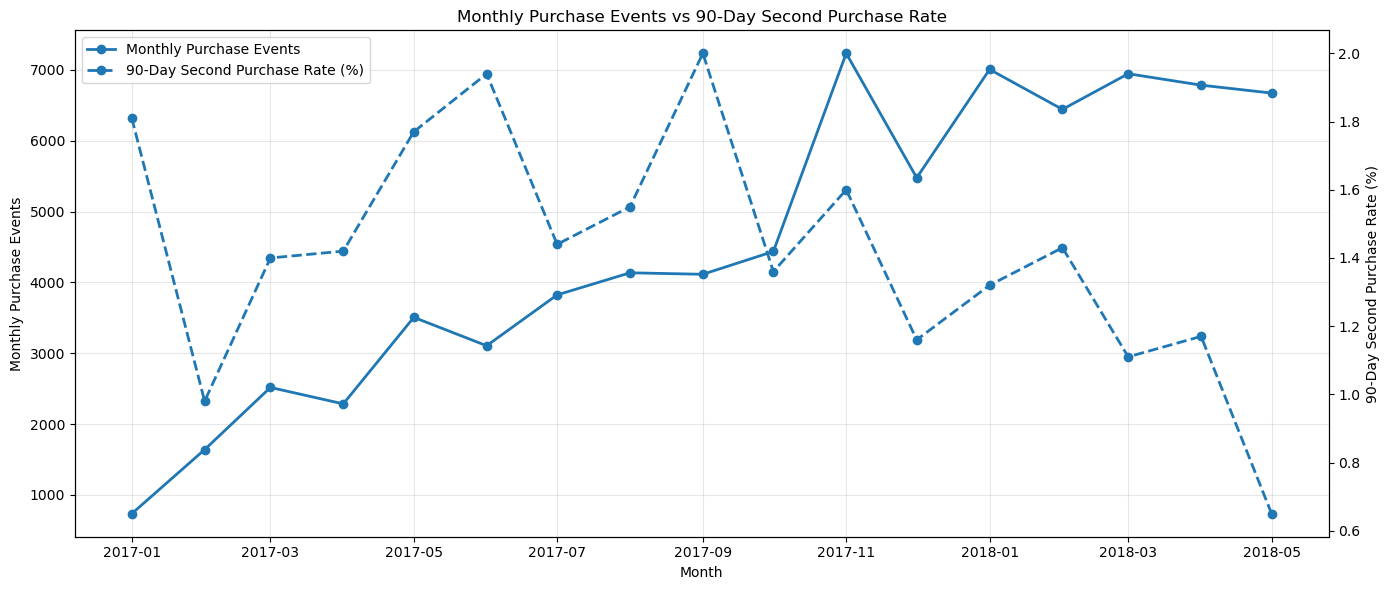

In [88]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 左軸：每月購買事件數
ax1.plot(
    compare_df_clean["first_purchase_month"],
    compare_df_clean["monthly_purchase_events"],
    marker="o",
    linewidth=2,
    label="Monthly Purchase Events"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Purchase Events")
ax1.tick_params(axis="y")

# 右軸：90天二購率
ax2 = ax1.twinx()

ax2.plot(
    compare_df_clean["first_purchase_month"],
    compare_df_clean["second_purchase_90d_rate_pct"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="90-Day Second Purchase Rate (%)"
)

ax2.set_ylabel("90-Day Second Purchase Rate (%)")
ax2.tick_params(axis="y")

# x 軸月份格式
ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)

# 合併圖例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Monthly Purchase Events vs 90-Day Second Purchase Rate")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

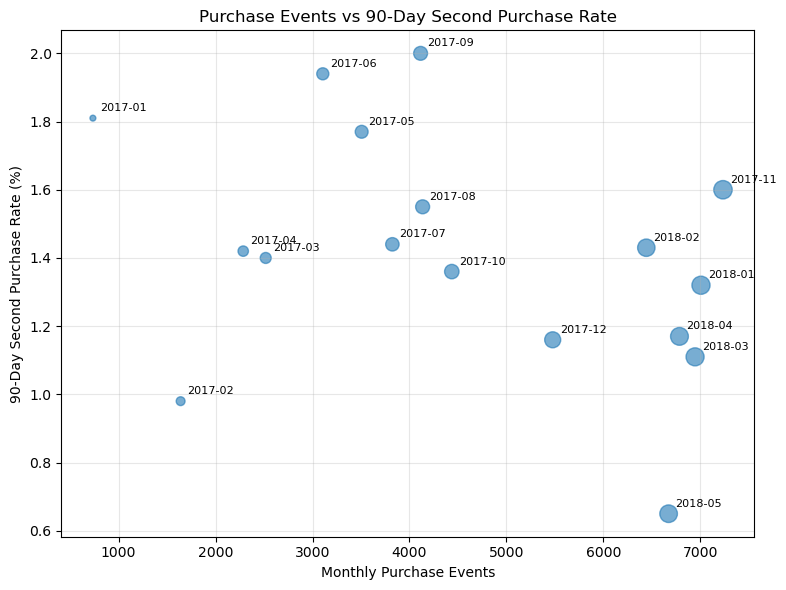

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(
    compare_df_clean["monthly_purchase_events"],
    compare_df_clean["second_purchase_90d_rate_pct"],
    s=compare_df_clean["cohort_size"] / 40,
    alpha=0.6
)

for _, row in compare_df_clean.iterrows():
    plt.annotate(
        row["first_purchase_month"].strftime("%Y-%m"),
        xy=(
            row["monthly_purchase_events"],
            row["second_purchase_90d_rate_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Monthly Purchase Events")
plt.ylabel("90-Day Second Purchase Rate (%)")
plt.title("Purchase Events vs 90-Day Second Purchase Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

月購買事件數增加，並沒有伴隨 90 天二購率提升。從圖上看，後期高交易量月份的二購率反而偏低，表示平台規模擴張沒有轉化成更好的留存效率。

In [91]:
# 利用 cohort size 計算加權相關係數

def weighted_corr(x, y, w):
    x = np.asarray(x)
    y = np.asarray(y)
    w = np.asarray(w)

    x_bar = np.average(x, weights=w)
    y_bar = np.average(y, weights=w)

    cov_xy = np.average((x - x_bar) * (y - y_bar), weights=w)
    var_x = np.average((x - x_bar) ** 2, weights=w)
    var_y = np.average((y - y_bar) ** 2, weights=w)

    return cov_xy / np.sqrt(var_x * var_y)

weighted_corr_value = weighted_corr(
    compare_df_clean["monthly_purchase_events"],
    compare_df_clean["second_purchase_90d_rate_pct"],
    compare_df_clean["cohort_size"]
)

print(f"Weighted correlation: {weighted_corr_value:.3f}")

Weighted correlation: -0.427


進一步將月購買事件數與每月首購 cohort 的 90 天二購率交叉分析後發現，兩者未呈現明顯正向關係。平台在 2018 年已達到較高交易規模，但 90 天二購率仍多數維持在 1%–1.5% 左右，甚至低於部分 2017 年中期 cohort。這表示平台交易量成長並未同步轉化為更好的首購後留存效率，平台成長可能較依賴新客或一次性交易，而非既有顧客關係的持續深化。